In [5]:
# from pathlib import Path
import pipeline_mcorr_cnmf as pmc

OSError: [WinError 182] The operating system cannot run %1. Error loading "c:\Users\Kyle\anaconda3\envs\mescore\lib\site-packages\torch\lib\fbgemm.dll" or one of its dependencies.

In [2]:
proc_folder = Path('D:/Analysis_2P/Data/Analysis/Scnn1aAi14_A2M0/01192024/run2/mesmerize')
mcorr_folder = 'c6b67a57-09ed-497a-8d61-4e4752cc6ade'
mcorr_mmap = f"{mcorr_folder}-cat_tiff_bt_els__d1_1024_d2_1024_d3_1_order_F_frames_1200.mmap"
mmap_path = proc_folder / mcorr_folder / mcorr_mmap
mmap_path

WindowsPath('D:/Analysis_2P/Data/Analysis/Scnn1aAi14_A2M0/01192024/run2/mesmerize/c6b67a57-09ed-497a-8d61-4e4752cc6ade/c6b67a57-09ed-497a-8d61-4e4752cc6ade-cat_tiff_bt_els__d1_1024_d2_1024_d3_1_order_F_frames_1200.mmap')

In [3]:
mcorr_tif_path = pmc.create_mcorr_movie(mmap_path, proc_folder / mcorr_folder, None, None, 'tiff', diff_corr=False, to_uint8=False)

NameError: name 'pmc' is not defined

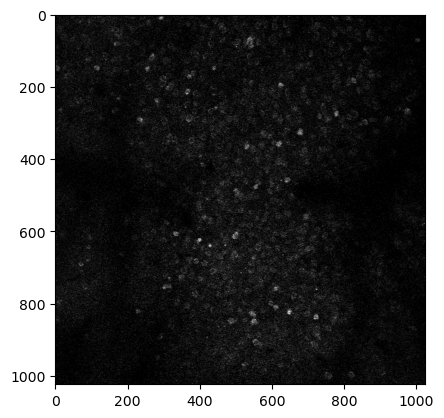

In [ ]:
#  Load the movie and display the first frame
import tifffile
import matplotlib.pyplot as plt
import numpy as np
mcorr_tif_file = tifffile.TiffFile(mcorr_tif_path)
mcorr_tif = mcorr_tif_file.asarray()
mcorr_tif_file.close()
plt.imshow(mcorr_tif[0], cmap='gray')
plt.show()


In [ ]:
# print the length of mcorr_tif
print(len(mcorr_tif))

1200


In [ ]:
# print other parameter of mcorr_tif
print(mcorr_tif.shape)

(1200, 1024, 1024)


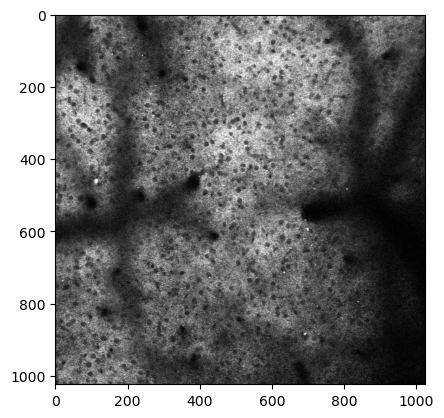

41
(41, 1024, 1024)


In [ ]:
zstack_tiff_file = tifffile.TiffFile("D:/Analysis_2P/Data/Scnn1aAi14_A2M0/01192024/ZSeries-01192024-1323-002/ZSeries-01192024-1323-002_Cycle00001_Ch1_000001.ome.tif")
zstack_tiff = zstack_tiff_file.asarray()
zstack_tiff_file.close()
plt.imshow(zstack_tiff[0], cmap='gray')
plt.show()
# print other parameter of mcorr_tif
print(len(zstack_tiff))
print(zstack_tiff.shape)

In [ ]:
# print the type of zstack_tiff
print(type(mcorr_tif))
print(type(zstack_tiff))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [ ]:
import numpy as np
from scipy.signal import correlate2d



# Initialize an array to store the cross-correlation results
cross_correlations = np.zeros((mcorr_tif.shape[0], zstack_tiff.shape[0], 1024, 1024))

# Loop through each image in mcorr_tif and each image in zstack_tiff
for i in range(mcorr_tif.shape[0]):
    for j in range(zstack_tiff.shape[0]):
        cross_correlations[i, j] = correlate2d(mcorr_tif[i], zstack_tiff[j], mode='same')

# Now, cross_correlations contains the cross-correlation of each possible pair of images


MemoryError: Unable to allocate 384. GiB for an array with shape (1200, 41, 1024, 1024) and data type float64